In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

In [3]:
df=pd.read_csv("./bmi_data_lab3.csv")

In [4]:
#statistical data
df.describe()

,Age,Height (Inches),Weight (Pounds),BMI
count,150.000000,146.000000,150.000000,145.000000
mean,26.413333,80.133994,129.703405,2.751724
std,5.206071,96.579662,88.179891,0.449244
min,18.000000,-130.926162,-161.994913,1.000000
25%,22.000000,66.599598,120.391125,3.000000
50%,26.500000,68.219095,128.538050,3.000000
75%,31.000000,69.432848,136.170900,3.000000
max,35.000000,665.465059,1110.621115,3.000000


In [5]:
#feature names& dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              150 non-null    object 
 1   Age              150 non-null    int64  
 2   Height (Inches)  146 non-null    float64
 3   Weight (Pounds)  150 non-null    float64
 4   BMI              145 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 6.0+ KB


In [6]:
# X=df.iloc[:,0:1] #Features
# y=df.iloc[:,-1] #BMI 

In [7]:
#rename columns
df=df.rename(columns={'Height (Inches)':'height_i','Weight (Pounds)':'weight_p'})

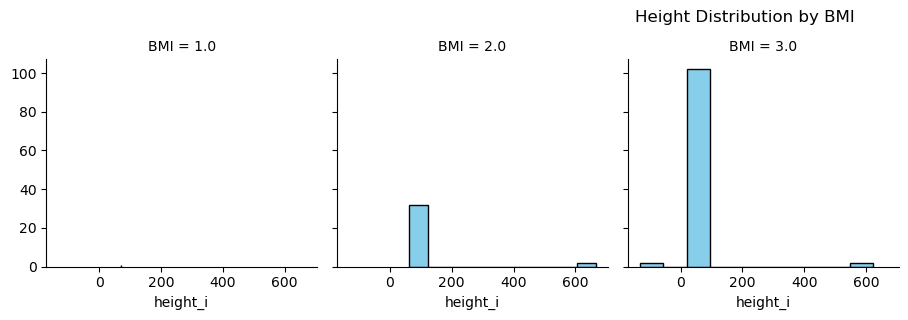

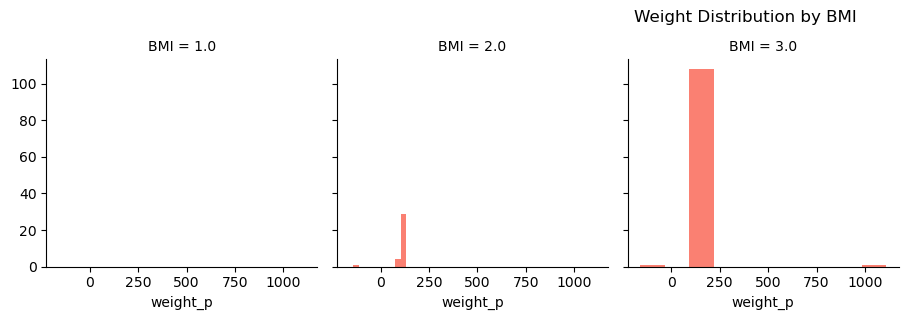

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

#plot height for each bmi value
g1=sns.FacetGrid(df,col='BMI',col_wrap=5,height=3)
g1.map(plt.hist,"height_i",bins=10,color='skyblue',edgecolor='black')
g1.figure.suptitle("Height Distribution by BMI", y=1.05)
plt.show()

#plot weight for each bmi value
g2=sns.FacetGrid(df,col="BMI",col_wrap=5,height=3)
g2.map(plt.hist,"weight_p",bins=10,color="salmon")
g2.figure.suptitle("Weight Distribution by BMI",y=1.05)
plt.show()

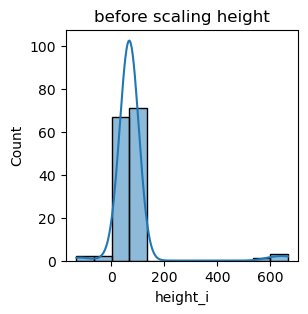

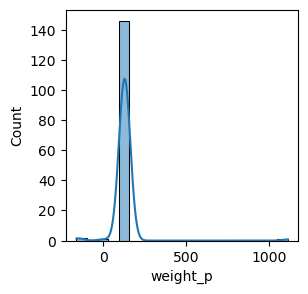

In [9]:

#before scaling height,weight features.
h_w=df[["height_i","weight_p"]]


#height
plt.figure(figsize=(3,3))
sns.histplot(h_w["height_i"],bins=12,kde=True)
plt.title("before scaling height")
plt.show()

#weight
plt.figure(figsize=(3,3))
sns.histplot(h_w["weight_p"],bins=20,kde=True)
plt.show()


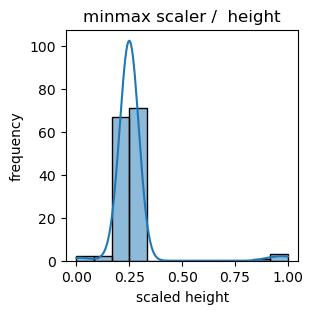

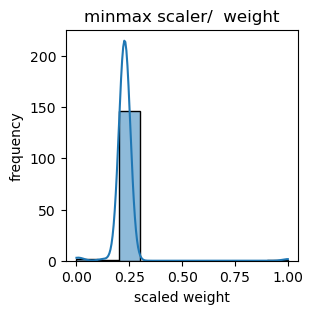

In [10]:
#plot scaling rsults for height and weight

h_w=df[["height_i","weight_p"]]

#minmax scaler
scaler=MinMaxScaler()
mm_scaled=scaler.fit_transform(h_w)
mm_scaled_df=pd.DataFrame(mm_scaled,columns=["height_i","weight_p"])

###plot
#height
plt.figure(figsize=(3,3))
sns.histplot(mm_scaled_df["height_i"],bins=12,kde=True)
plt.title("minmax scaler /  height")
plt.xlabel("scaled height")
plt.ylabel("frequency")
plt.show()

#weight
plt.figure(figsize=(3,3))
sns.histplot(mm_scaled_df["weight_p"],bins=10,kde=True)
plt.title("minmax scaler/  weight")
plt.xlabel("scaled weight")
plt.ylabel("frequency")
plt.show()


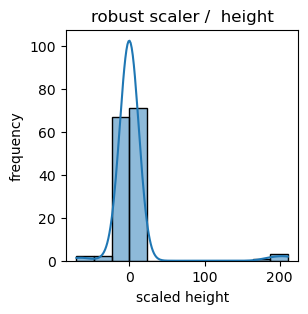

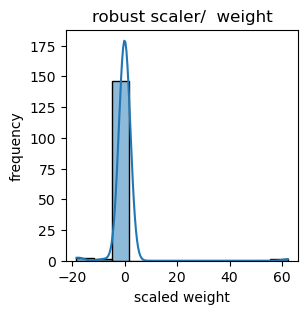

In [11]:
#robust scaler
scaler=RobustScaler()
rb_scaled=scaler.fit_transform(h_w)
rb_scaled_df=pd.DataFrame(rb_scaled,columns=["height_i","weight_p"])

###plot
#height
plt.figure(figsize=(3,3))
sns.histplot(rb_scaled_df["height_i"],bins=12,kde=True)
plt.title("robust scaler /  height")
plt.xlabel("scaled height")
plt.ylabel("frequency")
plt.show()

#weight
plt.figure(figsize=(3,3))
sns.histplot(rb_scaled_df["weight_p"],bins=12,kde=True)
plt.title("robust scaler/  weight")
plt.xlabel("scaled weight")
plt.ylabel("frequency")
plt.show()



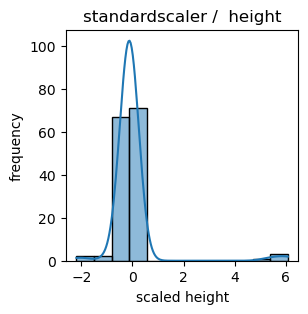

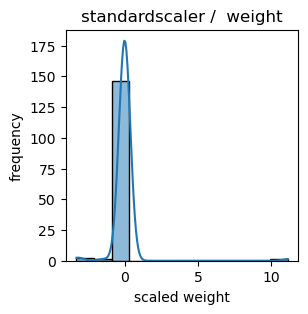

In [12]:
#StandardScaler

scaler=StandardScaler()
std_scaled=scaler.fit_transform(h_w)
std_scaled_df=pd.DataFrame(std_scaled,columns=["height_i","weight_p"])

###plot
#height
plt.figure(figsize=(3,3))
sns.histplot(std_scaled_df["height_i"],bins=12,kde=True)
plt.title("standardscaler /  height")
plt.xlabel("scaled height")
plt.ylabel("frequency")
plt.show()

#weight
plt.figure(figsize=(3,3))
sns.histplot(std_scaled_df["weight_p"],bins=12,kde=True)
plt.title("standardscaler /  weight")
plt.xlabel("scaled weight")
plt.ylabel("frequency")
plt.show()



 missing data

 by eye inspection

 height problem : 1,9,10,17,33,41,47,69,87,90,111,116  
 weight problem: 129,104,48
 

In [14]:
#height wrong data
height_indices=[1,9,10,17,33,41,47,69,87,90,111,116]

#weight wrong data
weight_indices=[129,104,48,147]

# 해당 인덱스의 값만 NaN으로 바꾸기
df.loc[height_indices, "height_i"] = np.nan

df.loc[weight_indices, "weight_p"] = np.nan


In [15]:
print("# of rows with nan",df.isna().any(axis=1).sum())

df.isna().sum()

# of rows with nan 18


Sex          0
Age          0
height_i    12
weight_p     4
BMI          5
dtype: int64

In [16]:
#extract all rows withoug nan
clean_df=df.dropna()

# fill nan with mean
clean_df1=clean_df.fillna(value=df.mean)

#fill nan with median
clean_df2=clean_df.fillna(value=df.median)

#bfill
clean_df3=clean_df.bfill()

#ffill
clean_df4=clean_df.ffill()


nan 자리에 들어갈 데이터를 예측하는거임 키랑 몸무게의 관계를 이용해서

몸무게로 키 예측 코드

In [17]:
#cleaning the input dataset by linearRegression

from sklearn.linear_model import LinearRegression

# 클린df 는 스케일 한 후  nan 을 drop 한거임.

# height is nan

X1=clean_df[['weight_p']]
#예측대상
y1=clean_df[['height_i']]

model1=LinearRegression()
# 몸무게 => 키 관계 학습함. 
model1.fit(X1,y1)


# #키가 nan 이고 몸무게는 있는 행만 뽑음
missing_height=df[df["height_i"].isna() & df["weight_p"].notna()]

#몸무게들로 키를 예측해줘 predict (// -> 이 값에 대해 예측한 결과 알려줌.)
# 예측 대상들의 몸무게만 추출.
# missing_height[['weight_p']] 

# model.predict 는  몸무게를 넣으면 자동적으로(?) 결과가 height  임. 
# 정상 and scaled 몸무게 넣어야함.
predicted_height=model1.predict(missing_height[['weight_p']])


# 회귀 계수와 절편 가져오기
slope1 = model1.coef_[0][0]      # 기울기
intercept1 = model1.intercept_[0]  # 절편

y_vals1 = slope1 * X1 + intercept1







키로 몸무게 예측 코드



In [ ]:
# weight is nan 
X2=clean_df[['height_i']]
y2=clean_df[['weight_p']]

model2=LinearRegression()
# 키로 몸무게 예측
model2.fit(X2,y2)


missing_weight=df[df["weight_p"].isna() & df["height_i"].notna()]
# 키를 넣으면 몸무게가 나옴
predicted_weight=model2.predict(missing_weight[['height_i']])

# 회귀 계수와 절편 가져오기
slope2 = model2.coef_[0][0]      # 기울기
intercept2 = model2.intercept_[0]  # 절편
y_vals2 = slope2 * X2 + intercept2

몸무게로 키 plot

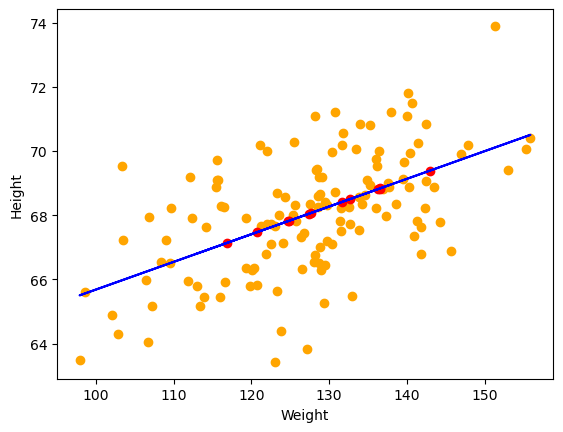

In [257]:
#후
plt.scatter(clean_df['weight_p'], clean_df['height_i'], 
            color='orange', label='clean Data', )

plt.xlabel("Weight")
plt.ylabel("Height")

plt.scatter(missing_height["weight_p"],predicted_height,color='red')

plt.plot(X1, y_vals1, color='blue')


키로 몸무게 예측한거 PLOT

In [ ]:

plt.scatter(clean_df['height_i'], clean_df['weight_p'], 
            color='orange', label='clean Data', )
plt.xlabel("height")
plt.ylabel("weight")

plt.scatter(missing_weight["height_i"],predicted_weight,color='red')

plt.plot(X2, y_vals2, color='blue')


In [ ]:
#female 이용해서 bmi 의 결측치 예측

X3=df[df['Sex']=='Female']
y3=clean_df['BMI']

model=LinearRegression()
model.fit(X3,y3)

missing_BMI=df[df["BMI"].isna()]
#FEMALE DATA 넣어야함
predicted_BMI=model.predict(X3)